In [1]:
try:
    from z3 import *
except ImportError:
    !pip install z3-solver
    from z3 import *

import pandas as pd
import random
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.7/31.7 MB 28.0 MB/s eta 0:00:00


In [2]:
random.seed(42)

n_workers = 30
workers = []

for i in range(n_workers):

    # NEW: worker skill level
    skill_level = random.choice(["low", "medium", "high"])

    # consent: most people give consent
    consent_given = random.random() > 0.3  # 70% True

    # monitoring depends on consent (IMPORTANT LOGIC)
    if consent_given:
        monitored = True
    else:
        monitored = random.random() > 0.8  # rare violation

    # automation depends on skill (VERY IMPORTANT)
    if skill_level == "low":
        automation_affected = random.random() > 0.3
    elif skill_level == "medium":
        automation_affected = random.random() > 0.6
    else:
        automation_affected = random.random() > 0.85

    # notification logic
    notified = automation_affected and (random.random() > 0.2)

    # retraining logic
    retraining_offered = automation_affected and (random.random() > 0.4)

    # privacy violation
    privacy_violation = monitored and not consent_given

    workers.append({
    "worker_id": i,
    "skill_level": skill_level,   # NEW
    "consent_given": consent_given,
    "monitored": monitored,
    "automation_affected": automation_affected,
    "notified": notified,
    "retraining_offered": retraining_offered,
    "privacy_violation": privacy_violation
})

df = pd.DataFrame(workers)
df.head()

,worker_id,skill_level,consent_given,monitored,automation_affected,notified,retraining_offered,privacy_violation
0,0,high,False,False,False,False,False,False
1,1,low,True,True,True,True,False,False
2,2,medium,False,False,False,False,False,False
3,3,high,False,False,False,False,False,False
4,4,high,True,True,False,False,False,False


The table above gives a simplified view of how worker-related decisions are represented in the prototype. The main ethical concerns at this stage are whether workers are monitored without consent, whether workers affected by automation are properly informed, and whether retraining support is provided.

In [3]:
df["risk"] = (
    (~df["consent_given"] & df["monitored"]) |
    (df["automation_affected"] & ~df["notified"]) |
    (df["automation_affected"] & ~df["retraining_offered"])
).astype(int)

df["risk"].value_counts()

,count
risk,
0,22
1,8


In [5]:
privacy_violations = int(df["privacy_violation"].sum())

automation_cases = df[df["automation_affected"] == True]
missing_notification = int((automation_cases["notified"] == False).sum())
missing_retraining = int((automation_cases["retraining_offered"] == False).sum())

print("WORKER AUDIT SUMMARY")

print(f"Total workers: {len(df)}")
print(f"Workers monitored without consent: {privacy_violations}")
print(f"Workers affected by automation: {len(automation_cases)}")
print(f"Automation cases without notification: {missing_notification}")
print(f"Automation cases without retraining: {missing_retraining}")

WORKER AUDIT SUMMARY
Total workers: 30
Workers monitored without consent: 1
Workers affected by automation: 10
Automation cases without notification: 3
Automation cases without retraining: 5


In [7]:
print("\nDETAILED ANALYSIS")


# % of violations
total = len(df)

privacy_pct = (privacy_violations / total) * 100
automation_pct = (len(automation_cases) / total) * 100

print(f"Privacy violation rate: {privacy_pct:.2f}%")
print(f"Automation impact rate: {automation_pct:.2f}%")


DETAILED ANALYSIS
Privacy violation rate: 3.33%
Automation impact rate: 33.33%


In [9]:
print("\nSKILL-LEVEL ANALYSIS")


skill_analysis = df.groupby("skill_level").agg({
    "automation_affected": "mean",
    "privacy_violation": "mean"
})

print(skill_analysis)#from results Low-skilled workers are more affected by automation


SKILL-LEVEL ANALYSIS
             automation_affected  privacy_violation
skill_level                                        
high                    0.090909           0.000000
low                     0.571429           0.000000
medium                  0.416667           0.083333


In [11]:
df["risk"] = (
    (df["privacy_violation"]) |
    (df["automation_affected"] & ~df["notified"]) |
    (df["automation_affected"] & ~df["retraining_offered"])
).astype(int)

print("\nRISK DISTRIBUTION")

print(df["risk"].value_counts())


RISK DISTRIBUTION
risk
0    22
1     8
Name: count, dtype: int64


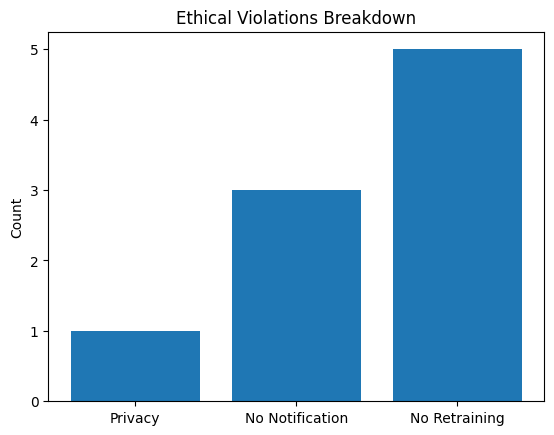

In [12]:
import matplotlib.pyplot as plt

labels = ["Privacy", "No Notification", "No Retraining"]
values = [privacy_violations, missing_notification, missing_retraining]

plt.bar(labels, values)
plt.title("Ethical Violations Breakdown")
plt.ylabel("Count")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Step 1: Create target variable (VERY IMPORTANT)
df["risk"] = (
    (df["privacy_violation"]) |
    (df["automation_affected"] & ~df["notified"]) |
    (df["automation_affected"] & ~df["retraining_offered"])
).astype(int)

# Step 2: Features
features = df[[
    "consent_given",
    "monitored",
    "automation_affected",
    "notified",
    "retraining_offered"
]].astype(int)

target = df["risk"]

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

# Step 4: Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Step 5: Evaluate
predictions = model.predict(X_test)

print("\nAI MODEL PERFORMANCE")

print(classification_report(y_test, predictions))


AI MODEL PERFORMANCE
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.75      0.86         4

    accuracy                           0.83         6
   macro avg       0.83      0.88      0.83         6
weighted avg       0.89      0.83      0.84         6



In [19]:
runs = []

for run_id in range(12):
    energy_score = random.randint(50, 120)
    high_energy = energy_score > 90
    review_triggered = high_energy and random.choice([True, True, False])

    runs.append({
        "run_id": run_id,
        "energy_score": energy_score,
        "high_energy": high_energy,
        "review_triggered": review_triggered
    })

df_energy = pd.DataFrame(runs)
df_energy

,run_id,energy_score,high_energy,review_triggered
0,0,120,True,True
1,1,56,False,False
2,2,119,True,True
3,3,61,False,False
4,4,80,False,False
5,5,71,False,False
6,6,102,True,True
7,7,111,True,True
8,8,101,True,True
9,9,71,False,False


In [22]:
energy_violations = df_energy[
    (df_energy["high_energy"] == True) &
    (df_energy["review_triggered"] == False)
]

print("ENVIRONMENTAL AUDIT SUMMARY")

print(f"Total simulation runs: {len(df_energy)}")
print(f"High-energy runs: {int(df_energy['high_energy'].sum())}")
print(f"High-energy runs without review: {len(energy_violations)}")


ENVIRONMENTAL AUDIT SUMMARY
Total simulation runs: 12
High-energy runs: 7
High-energy runs without review: 0


In [24]:
print(len(energy_violations))

0


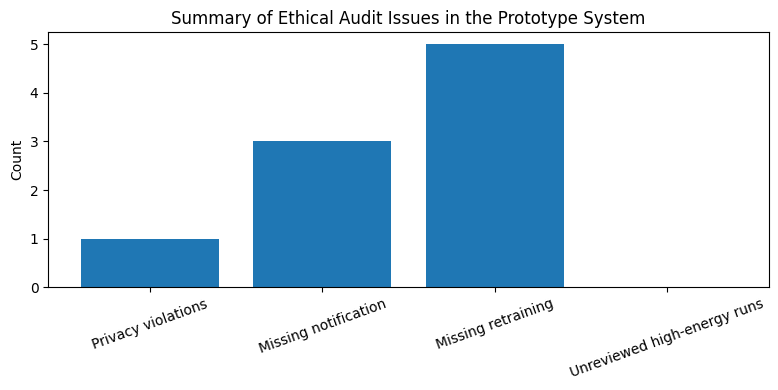

In [23]:
summary_counts = {
    "Privacy violations": privacy_violations,
    "Missing notification": missing_notification,
    "Missing retraining": missing_retraining,
    "Unreviewed high-energy runs": len(energy_violations)
}

plt.figure(figsize=(8, 4))
plt.bar(summary_counts.keys(), summary_counts.values())
plt.xticks(rotation=20)
plt.ylabel("Count")
plt.title("Summary of Ethical Audit Issues in the Prototype System")
plt.tight_layout()
plt.show()

In [25]:
k = 10

### EG1: Privacy and Consent

The first ethical goal is that workers should not be monitored unless consent has been verified.

In [28]:
consent = [Bool(f'consent_{i}') for i in range(k)]
consent_verified = [Bool(f'consent_verified_{i}') for i in range(k)]
monitored = [Bool(f'monitored_{i}') for i in range(k)]

s1 = Solver()

for i in range(k):
    s1.add(consent_verified[i] == consent[i])

for i in range(k):
    s1.add(Implies(monitored[i], consent_verified[i]))

eg1_property = And([
    Implies(Not(consent[i]), Not(monitored[i]))
    for i in range(k)
])

s1.add(Not(eg1_property))

result1 = s1.check()

print("EG1 — SAFETY: G(not consent -> not monitored)")
if result1 == unsat:
    print("RESULT: UNSAT — Property holds under the encoded system constraints.")
else:
    print("RESULT: SAT — Property violated.")
    m1 = s1.model()
    for i in range(k):
        print(
            f"t={i}: consent={m1.evaluate(consent[i])}, "
            f"consent_verified={m1.evaluate(consent_verified[i])}, "
            f"monitored={m1.evaluate(monitored[i])}"
        )


EG1 — SAFETY: G(not consent -> not monitored)
RESULT: UNSAT — Property holds under the encoded system constraints.


In [29]:
consent2 = [Bool(f'consent2_{i}') for i in range(k)]
consent_verified2 = [Bool(f'consent_verified2_{i}') for i in range(k)]
monitored2 = [Bool(f'monitored2_{i}') for i in range(k)]

s2 = Solver()

for i in range(k):
    s2.add(consent_verified2[i] == consent2[i])

s2.add(Not(consent2[4]))
s2.add(monitored2[4] == True)

eg1_violation_property = And([
    Implies(Not(consent2[i]), Not(monitored2[i]))
    for i in range(k)
])

s2.add(Not(eg1_violation_property))

result2 = s2.check()


print("EG1 — FORCED COUNTEREXAMPLE")

if result2 == sat:
    print("RESULT: SAT — Counterexample found.")
    m2 = s2.model()
    for i in range(k):
        marker = ""
        if str(m2.evaluate(consent2[i])) == "False" and str(m2.evaluate(monitored2[i])) == "True":
            marker = " <-- VIOLATION"
        print(
            f"t={i}: consent={m2.evaluate(consent2[i])}, "
            f"consent_verified={m2.evaluate(consent_verified2[i])}, "
            f"monitored={m2.evaluate(monitored2[i])}{marker}"
        )
else:
    print("RESULT: UNSAT")


EG1 — FORCED COUNTEREXAMPLE
RESULT: SAT — Counterexample found.
t=0: consent=False, consent_verified=False, monitored=monitored2_0
t=1: consent=False, consent_verified=False, monitored=monitored2_1
t=2: consent=False, consent_verified=False, monitored=monitored2_2
t=3: consent=False, consent_verified=False, monitored=monitored2_3
t=4: consent=False, consent_verified=False, monitored=True <-- VIOLATION
t=5: consent=False, consent_verified=False, monitored=monitored2_5
t=6: consent=False, consent_verified=False, monitored=monitored2_6
t=7: consent=False, consent_verified=False, monitored=monitored2_7
t=8: consent=False, consent_verified=False, monitored=monitored2_8
t=9: consent=False, consent_verified=False, monitored=monitored2_9


In [30]:
automated = [Bool(f'automated_{i}') for i in range(k)]
notified = [Bool(f'notified_{i}') for i in range(k)]
retrained = [Bool(f'retrained_{i}') for i in range(k)]

s3 = Solver()

for i in range(k):
    s3.add(Implies(automated[i], notified[i]))
    s3.add(Implies(automated[i], retrained[i]))

eg2_property = And([
    And(
        Implies(automated[i], notified[i]),
        Implies(automated[i], retrained[i])
    )
    for i in range(k)
])

s3.add(Not(eg2_property))

result3 = s3.check()


print("EG2 — SAFETY: G(automated -> notified AND retrained)")

if result3 == unsat:
    print("RESULT: UNSAT — Property holds under the encoded system constraints.")
else:
    print("RESULT: SAT — Property violated.")
    m3 = s3.model()
    for i in range(k):
        print(
            f"t={i}: automated={m3.evaluate(automated[i])}, "
            f"notified={m3.evaluate(notified[i])}, "
            f"retrained={m3.evaluate(retrained[i])}"
        )


EG2 — SAFETY: G(automated -> notified AND retrained)
RESULT: UNSAT — Property holds under the encoded system constraints.


In [31]:
automated4 = [Bool(f'automated4_{i}') for i in range(k)]
retrained4 = [Bool(f'retrained4_{i}') for i in range(k)]

s4 = Solver()

for i in range(k - 1):
    s4.add(Implies(automated4[i], Or(retrained4[i], retrained4[i + 1])))

eg2_liveness = And([
    Implies(automated4[i], Or([retrained4[j] for j in range(i, k)]))
    for i in range(k)
])

s4.add(Not(eg2_liveness))

result4 = s4.check()


print("EG2 — LIVENESS: G(automated -> F retrained)")

if result4 == unsat:
    print("RESULT: UNSAT — Liveness condition holds.")
else:
    print("RESULT: SAT — Liveness violated.")
    m4 = s4.model()
    for i in range(k):
        print(
            f"t={i}: automated={m4.evaluate(automated4[i])}, "
            f"retrained={m4.evaluate(retrained4[i])}"
        )


EG2 — LIVENESS: G(automated -> F retrained)
RESULT: SAT — Liveness violated.
t=0: automated=False, retrained=False
t=1: automated=False, retrained=False
t=2: automated=False, retrained=False
t=3: automated=False, retrained=False
t=4: automated=False, retrained=False
t=5: automated=False, retrained=False
t=6: automated=False, retrained=False
t=7: automated=True, retrained=True
t=8: automated=False, retrained=False
t=9: automated=True, retrained=False


In [32]:
high_energy = [Bool(f'high_energy_{i}') for i in range(k)]
review_triggered = [Bool(f'review_triggered_{i}') for i in range(k)]

s5 = Solver()

for i in range(k - 1):
    s5.add(Implies(high_energy[i], Or(review_triggered[i], review_triggered[i + 1])))

eg3_property = And([
    Implies(high_energy[i], Or([review_triggered[j] for j in range(i, k)]))
    for i in range(k)
])

s5.add(Not(eg3_property))

result5 = s5.check()


print("EG3 — ENVIRONMENTAL ACCOUNTABILITY: G(high_energy -> F review_triggered)")

if result5 == unsat:
    print("RESULT: UNSAT — Property holds.")
else:
    print("RESULT: SAT — Property violated.")
    m5 = s5.model()
    for i in range(k):
        print(
            f"t={i}: high_energy={m5.evaluate(high_energy[i])}, "
            f"review_triggered={m5.evaluate(review_triggered[i])}"
        )


EG3 — ENVIRONMENTAL ACCOUNTABILITY: G(high_energy -> F review_triggered)
RESULT: SAT — Property violated.
t=0: high_energy=False, review_triggered=False
t=1: high_energy=False, review_triggered=False
t=2: high_energy=False, review_triggered=False
t=3: high_energy=False, review_triggered=False
t=4: high_energy=False, review_triggered=False
t=5: high_energy=False, review_triggered=False
t=6: high_energy=False, review_triggered=False
t=7: high_energy=True, review_triggered=True
t=8: high_energy=False, review_triggered=False
t=9: high_energy=True, review_triggered=False


In [33]:
flagged = [Bool(f'flagged_{i}') for i in range(k)]
reduced = [Bool(f'reduced_{i}') for i in range(k)]

s6 = Solver()

for i in range(k - 1):
    s6.add(Implies(flagged[i], reduced[i + 1]))

bmc_property = And([
    Implies(flagged[i], reduced[i + 1])
    for i in range(k - 1)
])

s6.add(Not(bmc_property))

result6 = s6.check()


print("BOUNDED RESPONSE CHECK: G(flagged -> X reduced)")

if result6 == unsat:
    print("RESULT: UNSAT — Property holds over the bounded trace.")
else:
    print("RESULT: SAT — Counterexample found.")
    m6 = s6.model()
    for i in range(k - 1):
        print(
            f"t={i}: flagged={m6.evaluate(flagged[i])}, "
            f"reduced_at_t+1={m6.evaluate(reduced[i + 1])}"
        )


BOUNDED RESPONSE CHECK: G(flagged -> X reduced)
RESULT: UNSAT — Property holds over the bounded trace.


In [34]:
results = {
    "EG1 Safety: not consent -> not monitored": result1,
    "EG1 Forced Counterexample": result2,
    "EG2 Safety: automated -> notified and retrained": result3,
    "EG2 Liveness: automated -> eventually retrained": result4,
    "EG3 Environmental Accountability": result5,
    "Bounded Response: flagged -> next-step reduction": result6
}

summary_df = pd.DataFrame({
    "Property": list(results.keys()),
    "Result": ["HOLDS (unsat)" if r == unsat else "VIOLATED (sat)" for r in results.values()]
})

summary_df

,Property,Result
0,EG1 Safety: not consent -> not monitored,HOLDS (unsat)
1,EG1 Forced Counterexample,VIOLATED (sat)
2,EG2 Safety: automated -> notified and retrained,HOLDS (unsat)
3,EG2 Liveness: automated -> eventually retrained,VIOLATED (sat)
4,EG3 Environmental Accountability,VIOLATED (sat)
5,Bounded Response: flagged -> next-step reduction,HOLDS (unsat)
